## Human In The Loop

**Review:** For human-in-the-loop, we often want to see our graph outputs as it's running.

We laid the foundations for this with streaming.

### Goals

Now, let's talk about the motivations for human-in-the-loop:

1. **Approval** – We can interrupt our agent, surface state to a user, and allow the user to accept an action.

2. **Debugging** – We can rewind the graph to reproduce or avoid issues.

3. **Editing** – You can modify the state.

LangGraph offers several ways to get or update agent state to support various human-in-the-loop workflows.


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")

# llm = ChatOpenAI(model="gpt-4o")

result = llm.invoke("Hello")

result

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.029844386, 'completion_tokens_details': None, 'prompt_time': 0.002209815, 'prompt_tokens_details': None, 'queue_time': 0.049361844, 'total_time': 0.032054201}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea662-4245-7570-8393-762d2f9e56d4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [3]:
### Custom tools 
### Custom Functions
from langchain_core.tools import tool

@tool
def multiply(a:str, b:str) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return int(a) * int(b)


# This will be a tool
@tool
def add(a:str, b:str) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return int(a) + int(b)

@tool
def divide(a:str,b:str)-> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return int(a) / int(b) 

tools = [add,multiply,divide]
tools

[StructuredTool(name='add', description='Adds a and b.\n\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x0000020D715889E0>),
 StructuredTool(name='multiply', description='Multiply a and b.\n\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000020D7136CCA0>),
 StructuredTool(name='divide', description='Adds a and b.\n\nArgs:\n    a: first int\n    b: second int', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x0000020D71588BF0>)]

In [4]:
## Integrate tools with LLms
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020D71232900>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000020D71233380>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a and b.\n\nArgs:\n    a: first int\n    b: second int', 'parameters': {'properties': {'a': {'type': 'string'}, 'b': {'type': 'string'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b.\n\nArgs:\n    a: first 

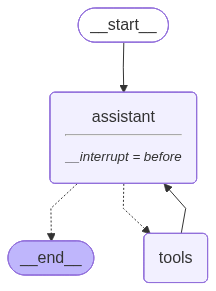

In [6]:
## Workflow
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph

from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage

##system message
sys_msg = SystemMessage(content="Hey You are a helpful assistant tasked with performing arithmetic operations")

##Node 
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state['messages'])]}

## Graph 
builder = StateGraph(MessagesState)

#Define nodes 
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

# Define edges
builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",

    tools_condition
)
builder.add_edge("tools","assistant")

memory = MemorySaver()

## Human in the loop
graph = builder.compile(interrupt_before=["assistant"],checkpointer=memory)

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [7]:
thread={"configurable":{"thread_id":"123"}}
intial_input = {"messages":HumanMessage(content="Multiply 2 and 3")}

In [8]:
for event in graph.stream(intial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [12]:
graph.get_state_history(thread)

<generator object Pregel.get_state_history at 0x0000020D71C32DA0>

In [10]:
state = graph.get_state(thread)
state.next

('assistant',)

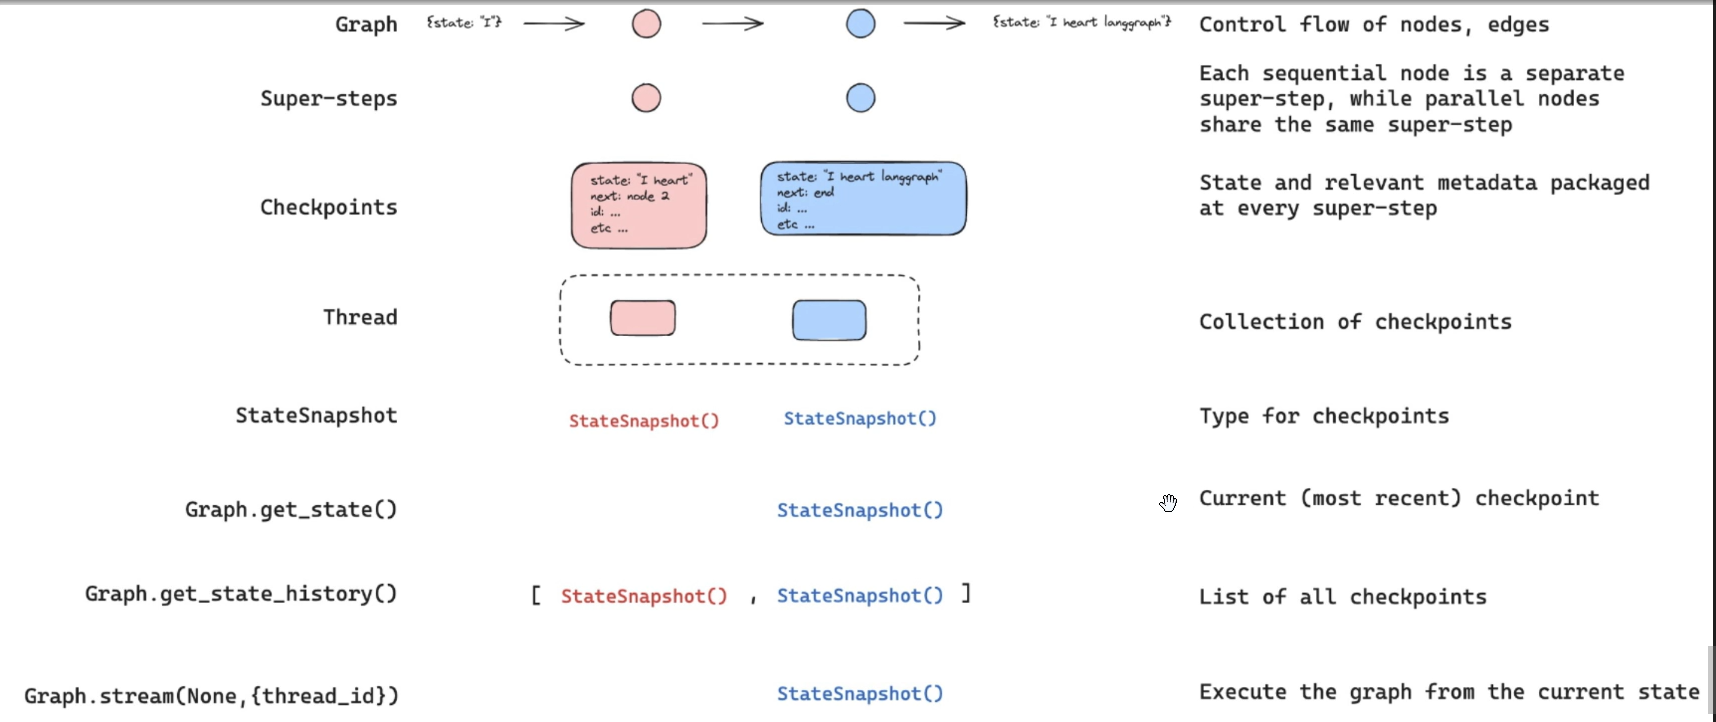

In [14]:
## Contuinue the execution
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (sbycp76v9)
 Call ID: sbycp76v9
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [15]:
state = graph.get_state(thread)
state.next

('assistant',)

In [16]:
## Contuinue the execution
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


### Edit Human Feedback

In [17]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

thread = {"configurable": {"thread_id": "1"}}

for event in graph.stream(initial_input,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [18]:
state = graph.get_state(thread)
state.next

('assistant',)

In [19]:
graph.update_state(thread,{"messages":[HumanMessage(content="No,please multiply 15 and 6")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f16319e-b181-675d-8001-f634eb6d9e3c'}}

In [20]:
new_state = graph.get_state(thread).values

for m in new_state['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No,please multiply 15 and 6


In [21]:
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

No,please multiply 15 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (zv6yw0nrb)
 Call ID: zv6yw0nrb
  Args:
    a: 15
    b: 6
================================= Tool Message =================================
Name: multiply

90


In [22]:
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

90
================================== Ai Message ==================================

The result of multiplying 15 and 6 is 90.


### Workflow Wait for the User input
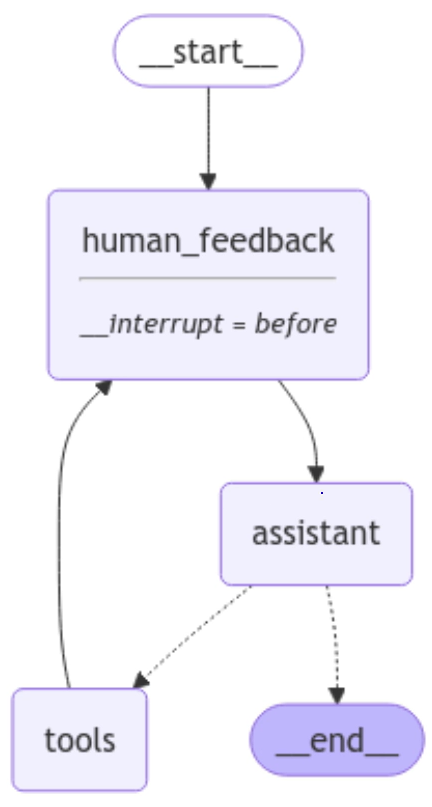

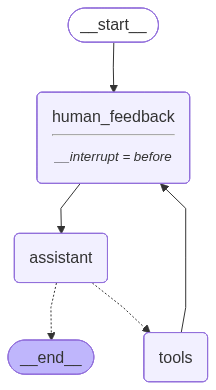

In [25]:
##system message
sys_msg = SystemMessage(content="Hey You are a helpful assistant tasked with performing arithmetic operations")

## Human Feedback node

def human_feedback(state:MessagesState):
    pass 

### Assistant tool
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg]+state['messages'])]}

## Graph 
builder = StateGraph(MessagesState)

##Define nodes: these do the work 
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))
builder.add_node("human_feedback",human_feedback)

##Define the edges
builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools","human_feedback")

memory = MemorySaver()

graph = builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

## Get user input
user_input = input("Tell me how you want to update the state:")

graph.update_state(thread,{"messages": user_input},as_node="human_feedback")

# Continue the graph execution
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

please multiply 5 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (z0r1q346b)
 Call ID: z0r1q346b
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

30


In [27]:
# Continue the graph execution
for event in graph.stream(None,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

30
================================== Ai Message ==================================

The result of multiplying 5 and 6 is 30.
